# Что меняется между вдохом и выдохом: осмотр данных

Ноутбук существует потому, что три ошибки подряд прошли все автоматические проверки и
были видны только глазами. Он не считает результат — он показывает, можно ли верить
тому, что считает конвейер.

Порядок такой: сначала проверяется, правильно ли поняты оси тома, потом — правильно ли
выделены тело и лёгкое, и только потом смотрится, что изменилось между фазами.

Данные: пары DIR-Lab COPDgene (`iBHCT` / `eBHCT`), единственный набор на диске с полным
торсом и обеими фазами.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage

from breathgeom.io.dirlab import load_copdgene
from breathgeom.measure.wall import AIR_HU, Side, WallParams, body_mask, lung_mask

# Каталог с распакованными случаями DIR-Lab: copd1/copd1_iBHCT.img и т.д.
DIRLAB_ROOT = Path("E:/КТ папка/dirlab_copdgene/extracted")
CASE = "copd1"

MP = WallParams()
plt.rcParams["figure.dpi"] = 110

## 1. Загрузка и отчёт об ориентации

Формат DIR-Lab безголовый: ни размеров, ни шага, ни ориентации, ни шкалы интенсивностей.
Всё это либо берётся из опубликованной таблицы, либо восстанавливается из самого
изображения — и тогда обязано быть предъявлено, а не принято на веру.

Ориентация определяется **один раз на человека** по более наполненному скану и
применяется к обеим фазам: две фазы одного человека не могут иметь разную анатомию.

In [2]:
folder = DIRLAB_ROOT / CASE
_, _, orientation = load_copdgene(folder / f"{CASE}_iBHCT.img", CASE)

volumes = {}
for tag in ("iBHCT", "eBHCT"):
    volume, spacing, _ = load_copdgene(
        folder / f"{CASE}_{tag}.img", CASE, orientation=orientation
    )
    volumes[tag] = volume
sx, sy, sz = spacing

print(f"{CASE}: {volumes['iBHCT'].shape}, шаг {sx} x {sy} x {sz} мм")
print()
print(f"позвоночник смещён на {orientation.spine_offset_px:+.0f} px -> "
      f"задняя сторона у больших индексов: {orientation.posterior_is_high_row}")
print(f"асимметрия воздуха {orientation.lung_asymmetry:+.3f} -> "
      f"правая сторона у больших индексов: {orientation.right_is_high_index}")
print(f"каудальный избыток воздуха {orientation.caudal_air_excess:+.3f}, "
      f"резкость диафрагмы {orientation.diaphragm_sharpness_ratio:.2f} -> "
      f"голова у больших индексов: {orientation.superior_is_high_index}")
print(f"признаки головы/ног согласованы: {orientation.sides_agree}")
print(f"пик воздуха восстановлен на {orientation.air_peak_hu:.0f} HU")

copd1: (512, 512, 121), шаг 0.625 x 0.625 x 2.5 мм

позвоночник смещён на +57 px -> задняя сторона у больших индексов: True
асимметрия воздуха -0.028 -> правая сторона у больших индексов: False
каудальный избыток воздуха -0.079, резкость диафрагмы 0.65 -> голова у больших индексов: False
признаки головы/ног согласованы: True
пик воздуха восстановлен на -995 HU


## 2. Проверка осей по анатомии

Это главная проверка ноутбука. Оси не подписаны в файле, и ошибка в них не вызывает
никакого исключения — она просто делает все дальнейшие числа бессмысленными.

Два независимых признака:

- **позвонок** — самая плотная структура, лежит сзади и по средней линии. По
  передне-задней оси его гистограмма обязана быть смещена к одному краю, по
  лево-правой — иметь пик в центре;
- **сердце** смещает левое лёгкое, поэтому по лево-правой оси воздух распределён
  асимметрично, а по передне-задней — примерно симметрично.

Если картина обратная, оси перепутаны.

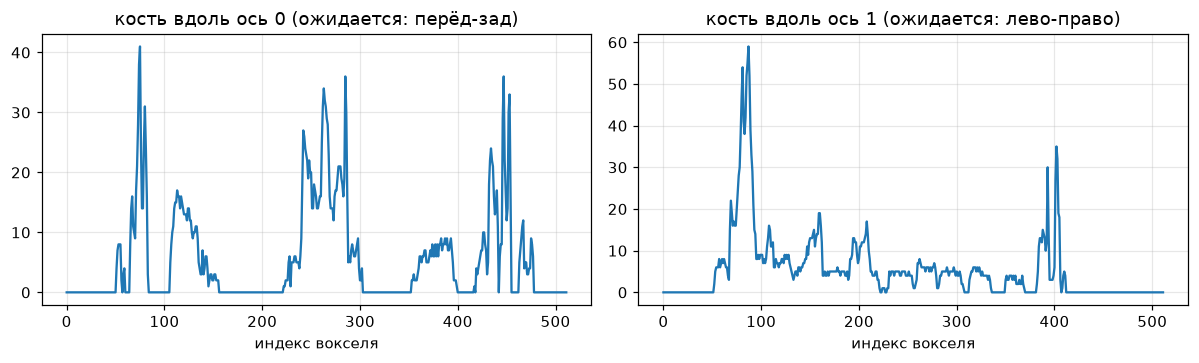

воздух по ось 0: 42382 / 43535, отношение 1.03
воздух по ось 1: 43237 / 42680, отношение 0.99


In [3]:
volume = volumes["iBHCT"]
middle = volume.shape[2] // 2
slice_hu = volume[:, :, middle].astype(np.int32)
body = body_mask(slice_hu, MP)
bone = body & (slice_hu > 300)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, axis, name in ((ax[0], 0, "ось 0 (ожидается: перёд-зад)"),
                      (ax[1], 1, "ось 1 (ожидается: лево-право)")):
    counts = bone.sum(axis=1 - axis)
    a.plot(counts)
    a.set_title(f"кость вдоль {name}")
    a.set_xlabel("индекс вокселя")
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

air = body & (slice_hu < AIR_HU)
rows, columns = np.where(air)
for axis, values, name in ((0, rows, "ось 0"), (1, columns, "ось 1")):
    spanned = np.flatnonzero(body.any(axis=1 - axis))
    midline = 0.5 * (spanned[0] + spanned[-1])
    low = int((values < midline).sum())
    high = int((values >= midline).sum())
    print(f"воздух по {name}: {low} / {high}, отношение {high / max(low, 1):.2f}")

Ожидаемое для корректных осей: по **лево-правой** оси кость даёт узкий пик в центре
(позвонок на средней линии), по **передне-задней** — смещение к одному краю. Воздух
асимметричен по лево-правой оси и симметричен по передне-задней.

## 3. Профили по срезам

Три величины, каждая ловит свой класс ошибок:

- **сечение тела** — меняется ли поза и укладка между фазами;
- **сечение правого лёгкого** — работает ли выделение лёгкого вообще;
- **наружная граница сбоку** — двигается ли кожа.

Скачки сечения лёгкого между соседними срезами анатомически невозможны. Если они есть,
маска выбирает разные объекты, и всё, что построено на ней, недействительно.

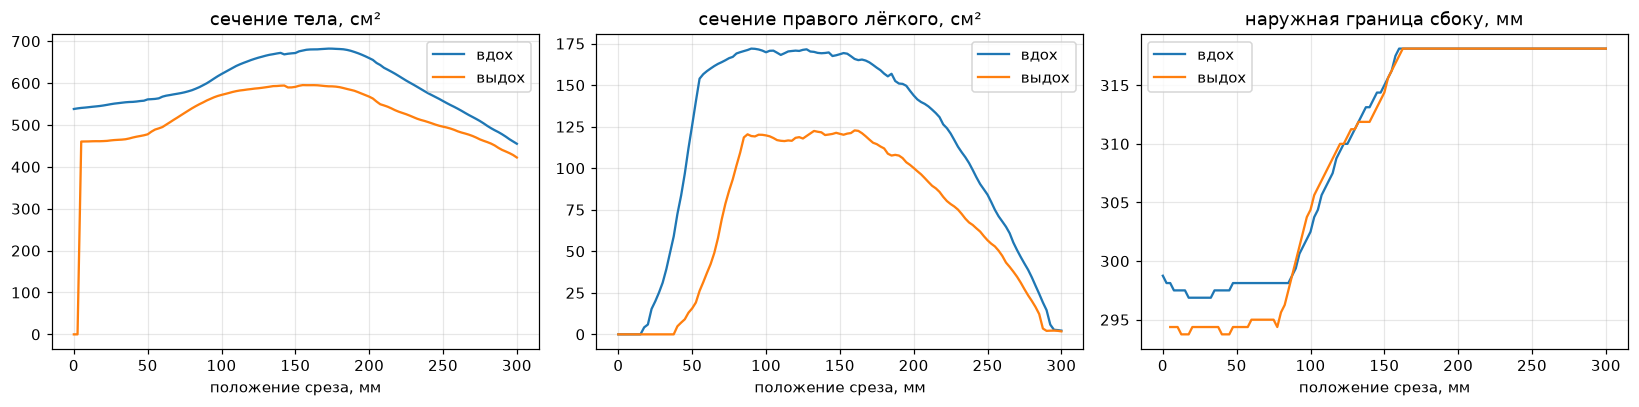

наибольший скачок сечения лёгкого между соседними срезами: вдох 15 см², выдох 11 см²
Скачок в десятки см² означает, что маска переключается между разными объектами.


In [4]:
def profiles(volume):
    body_area, lung_area, lateral = [], [], []
    for index in range(volume.shape[2]):
        current = volume[:, :, index]
        mask = body_mask(current, MP)
        if mask is None:
            body_area.append(0.0)
            lung_area.append(0.0)
            lateral.append(np.nan)
            continue
        body_area.append(float(mask.sum()) * sx * sy / 100.0)
        lung = lung_mask(current, mask, Side.RIGHT, MP)
        lung_area.append(float(lung.sum()) * sx * sy / 100.0 if lung is not None else 0.0)
        occupied = np.where(mask.any(axis=1))[0]
        lateral.append(float(occupied.max()) * sx)
    return map(np.array, (body_area, lung_area, lateral))


body_in, lung_in, lat_in = profiles(volumes["iBHCT"])
body_ex, lung_ex, lat_ex = profiles(volumes["eBHCT"])
z = np.arange(volumes["iBHCT"].shape[2]) * sz

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
panels = (
    (body_in, body_ex, "сечение тела, см²"),
    (lung_in, lung_ex, "сечение правого лёгкого, см²"),
    (lat_in, lat_ex, "наружная граница сбоку, мм"),
)
for a, (vi, ve, title) in zip(ax, panels, strict=True):
    a.plot(z, vi, label="вдох")
    a.plot(z, ve, label="выдох")
    a.set_title(title)
    a.set_xlabel("положение среза, мм")
    a.legend()
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

jump_in = np.abs(np.diff(lung_in)).max()
jump_ex = np.abs(np.diff(lung_ex)).max()
print(f"наибольший скачок сечения лёгкого между соседними срезами: "
      f"вдох {jump_in:.0f} см², выдох {jump_ex:.0f} см²")
print("Скачок в десятки см² означает, что маска переключается между разными объектами.")

## 4. Сколько компонент видит маска лёгкого

Правило «компонента с наибольшим центроидом по лево-правой оси = правое лёгкое» ломается,
когда лёгкие соединены: тогда возвращаются оба сразу. Здесь видно, на каких срезах это
происходит.

In [5]:
volume = volumes["iBHCT"]
rows = []
for index in range(0, volume.shape[2], 4):
    current = volume[:, :, index]
    mask = body_mask(current, MP)
    if mask is None:
        continue
    air = ndimage.binary_opening(mask & (current < AIR_HU), np.ones((3, 3), dtype=bool))
    labels, count = ndimage.label(air)
    if count == 0:
        continue
    sizes = ndimage.sum(air, labels, range(1, count + 1))
    kept = [size for size in sizes if size > MP.min_lung_component_px]
    chosen = lung_mask(current, mask, Side.RIGHT, MP)
    rows.append((
        index,
        len(kept),
        float(sum(kept)) * sx * sy / 100.0,
        float(chosen.sum()) * sx * sy / 100.0 if chosen is not None else 0.0,
    ))

print(f"{'срез':>5} {'компонент':>10} {'весь воздух':>12} {'выбрано':>9}  диагноз")
for index, count, total, picked in rows:
    if picked == 0.0:
        verdict = "ничего не выбрано"
    elif picked > 0.75 * total and count == 1:
        verdict = "ОБА ЛЁГКИХ СЛИТЫ В ОДНО"
    elif picked < 0.2 * total:
        verdict = "выбран посторонний объект"
    else:
        verdict = "похоже на одно лёгкое"
    print(f"{index:>5} {count:>10} {total:>12.0f} {picked:>9.0f}  {verdict}")

 срез  компонент  весь воздух   выбрано  диагноз
    0          2           12         0  ничего не выбрано
    4          2           12         0  ничего не выбрано
    8          4           20         6  похоже на одно лёгкое
   12          3           48        31  похоже на одно лёгкое
   16          2          117        72  похоже на одно лёгкое
   20          2          222       126  похоже на одно лёгкое
   24          3          290       158  похоже на одно лёгкое
   28          2          290       164  похоже на одно лёгкое
   32          1          297       169  похоже на одно лёгкое
   36          2          306       172  похоже на одно лёгкое
   40          2          310       170  похоже на одно лёгкое
   44          2          314       168  похоже на одно лёгкое
   48          1          323       171  похоже на одно лёгкое
   52          3          330       170  похоже на одно лёгкое
   56          3          337       169  похоже на одно лёгкое
   60         

## 5. Контуры обеих фаз на одном срезе

Сплошная линия — тело, пунктир — правое лёгкое. Синий вдох, оранжевый выдох.

Здесь видно сразу и то, ради чего ноутбук затевался — насколько сместилось лёгкое и
насколько кожа, — и то, совпадают ли фазы по укладке вообще. Заметное расхождение
контуров тела означает, что человек лежал по-разному, и разность фаз смешана с
разностью позы.

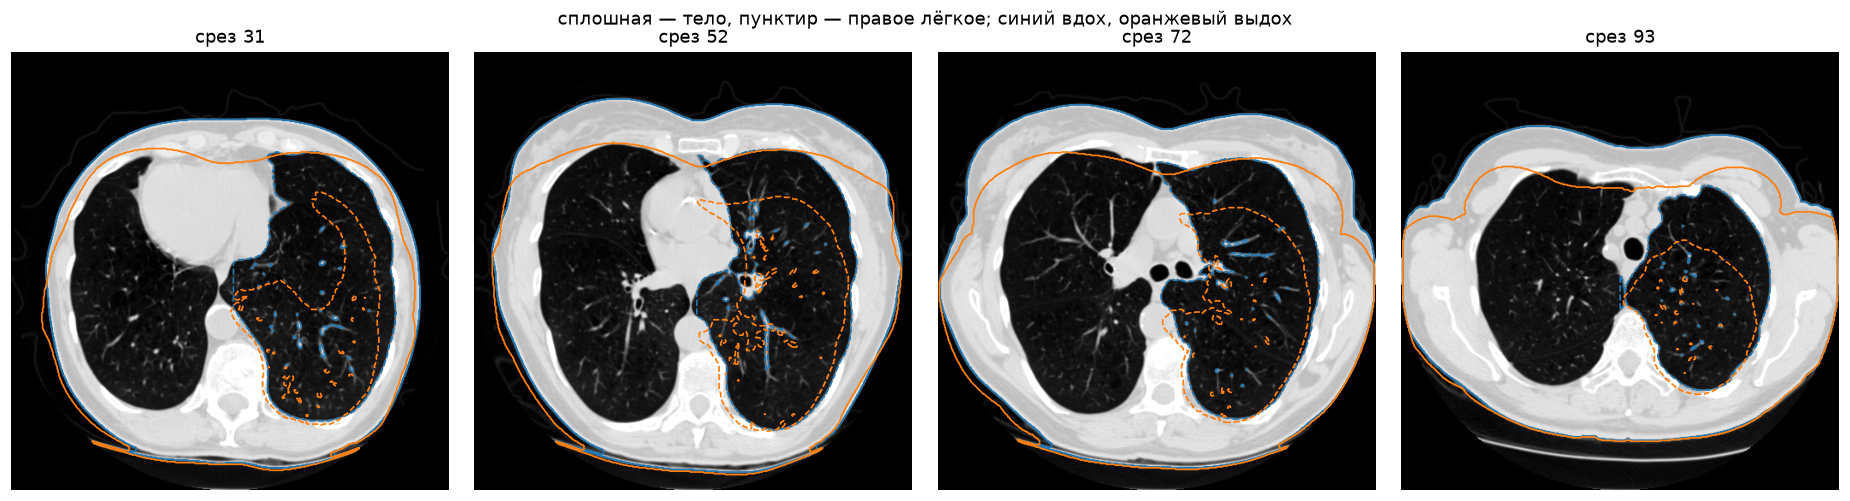

In [6]:
present = [k for k in range(volumes["iBHCT"].shape[2]) if lung_in[k] > 20]
levels = np.linspace(min(present), max(present), 6)[1:5].astype(int)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for a, index in zip(axes, levels, strict=True):
    a.imshow(volumes["iBHCT"][:, :, index].T, cmap="gray", vmin=-1000, vmax=200,
             origin="lower")
    for tag, colour in (("iBHCT", "tab:blue"), ("eBHCT", "tab:orange")):
        current = volumes[tag][:, :, index]
        mask = body_mask(current, MP)
        if mask is None:
            continue
        a.contour(mask.T, levels=[0.5], colors=colour, linewidths=1.1)
        lung = lung_mask(current, mask, Side.RIGHT, MP)
        if lung is not None:
            a.contour(lung.T, levels=[0.5], colors=colour, linewidths=1.1, linestyles="--")
    a.set_title(f"срез {index}")
    a.axis("off")
fig.suptitle("сплошная — тело, пунктир — правое лёгкое; синий вдох, оранжевый выдох")
fig.tight_layout()
plt.show()

## 6. Изменение наружной поверхности отдельно

Кожа и лёгкое меняются по-разному, и для двуслойной импедансной модели важна именно
разность: если кожа стоит, а лёгкое отходит, слой между ними толстеет.

Ниже — радиус тела и радиус лёгкого от общего центра, по углу, на одном уровне.

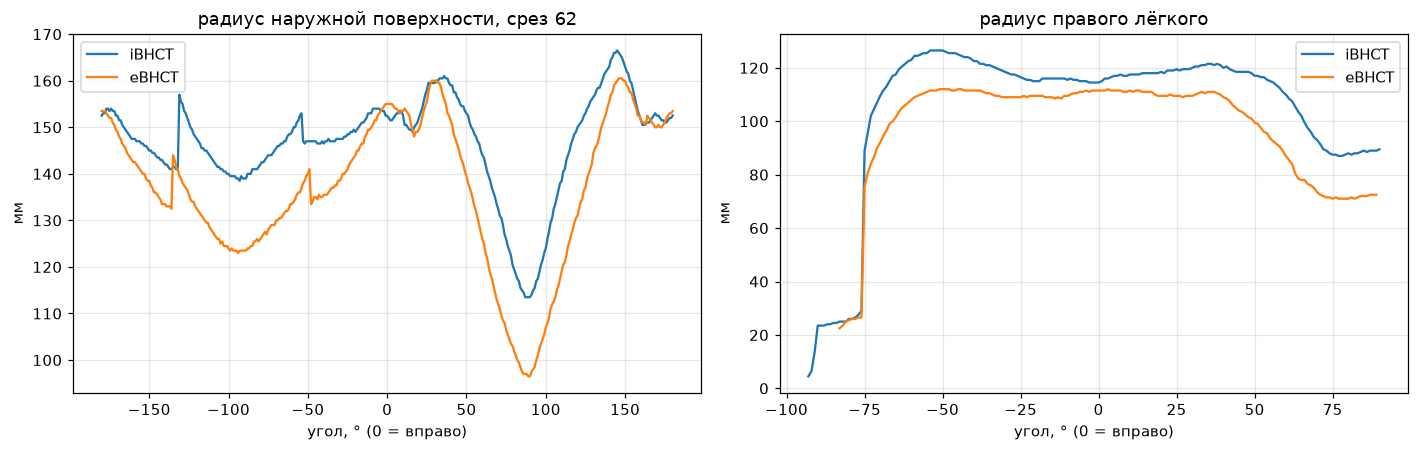

In [7]:
index = int(np.median(levels))
angles = np.radians(np.linspace(-180, 180, 361))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for tag, colour in (("iBHCT", "tab:blue"), ("eBHCT", "tab:orange")):
    current = volumes[tag][:, :, index]
    mask = body_mask(current, MP)
    lung = lung_mask(current, mask, Side.RIGHT, MP)
    centre = ndimage.center_of_mass(mask)
    radii = np.arange(1, 400) * 0.5
    body_r, lung_r = [], []
    for angle in angles:
        rr = np.clip(np.round(centre[0] + radii * np.cos(angle) / sx).astype(int),
                     0, mask.shape[0] - 1)
        cc = np.clip(np.round(centre[1] + radii * np.sin(angle) / sy).astype(int),
                     0, mask.shape[1] - 1)
        hit = np.flatnonzero(mask[rr, cc])
        body_r.append(radii[hit[-1]] if hit.size else np.nan)
        if lung is not None:
            hit = np.flatnonzero(lung[rr, cc])
            lung_r.append(radii[hit[-1]] if hit.size else np.nan)
        else:
            lung_r.append(np.nan)
    ax[0].plot(np.degrees(angles), body_r, color=colour, label=tag)
    ax[1].plot(np.degrees(angles), lung_r, color=colour, label=tag)
ax[0].set_title(f"радиус наружной поверхности, срез {index}")
ax[1].set_title("радиус правого лёгкого")
for a in ax:
    a.set_xlabel("угол, ° (0 = вправо)")
    a.set_ylabel("мм")
    a.legend()
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Что делать с результатом

Ноутбук считается пройденным, только если выполнено всё:

1. позвонок даёт пик в центре по лево-правой оси и смещён к краю по передне-задней;
2. сечение правого лёгкого меняется по срезам плавно, без скачков в десятки см²;
3. ни на одном срезе маска не выбирает оба лёгких сразу;
4. контуры тела двух фаз совпадают в пределах нескольких миллиметров.

Невыполнение пункта 2 или 3 означает, что выделение лёгкого не годится и любые толщины,
посчитанные на нём, недействительны — независимо от того, насколько устойчивыми они
выглядят при вариации параметров.

Невыполнение пункта 4 означает, что фазы не совмещены и разность содержит вклад позы.

---

## 8. Совмещение фаз

Всё дальнейшее сравнивает две фазы, а значит требует общей системы координат. Совмещение
жёсткое и опирается на **позвоночник**: рёбра поворачиваются при каждом вдохе, то есть
являются частью изучаемого движения, и метрика с ними поглотила бы часть эффекта в
трансформацию.

In [8]:
from breathgeom.measure.align import rigid_align

inhale = volumes["iBHCT"]
exhale, alignment = rigid_align(inhale, volumes["eBHCT"], spacing)

print(f"сдвиг {alignment.shift_mm:.2f} мм "
      f"{[round(v, 2) for v in alignment.translation_mm]}")
print(f"поворот, град {[round(v, 2) for v in alignment.rotation_deg]}")
print(f"перекрытие позвоночников по Дайсу: "
      f"{alignment.column_dice_before:.3f} -> {alignment.column_dice_after:.3f}")

сдвиг 2.05 мм [-1.7, -0.43, -1.07]
поворот, град [0.64, -0.41, -1.35]
перекрытие позвоночников по Дайсу: 0.306 -> 0.507


## 9. Границы на обеих подложках

Один и тот же набор контуров рисуется дважды: сверху на изображении вдоха, снизу на
изображении выдоха. Контур, который на своей подложке лежит по краю ткани, а на чужой уходит
внутрь или наружу — и есть искомое смещение, увиденное без единого числа.

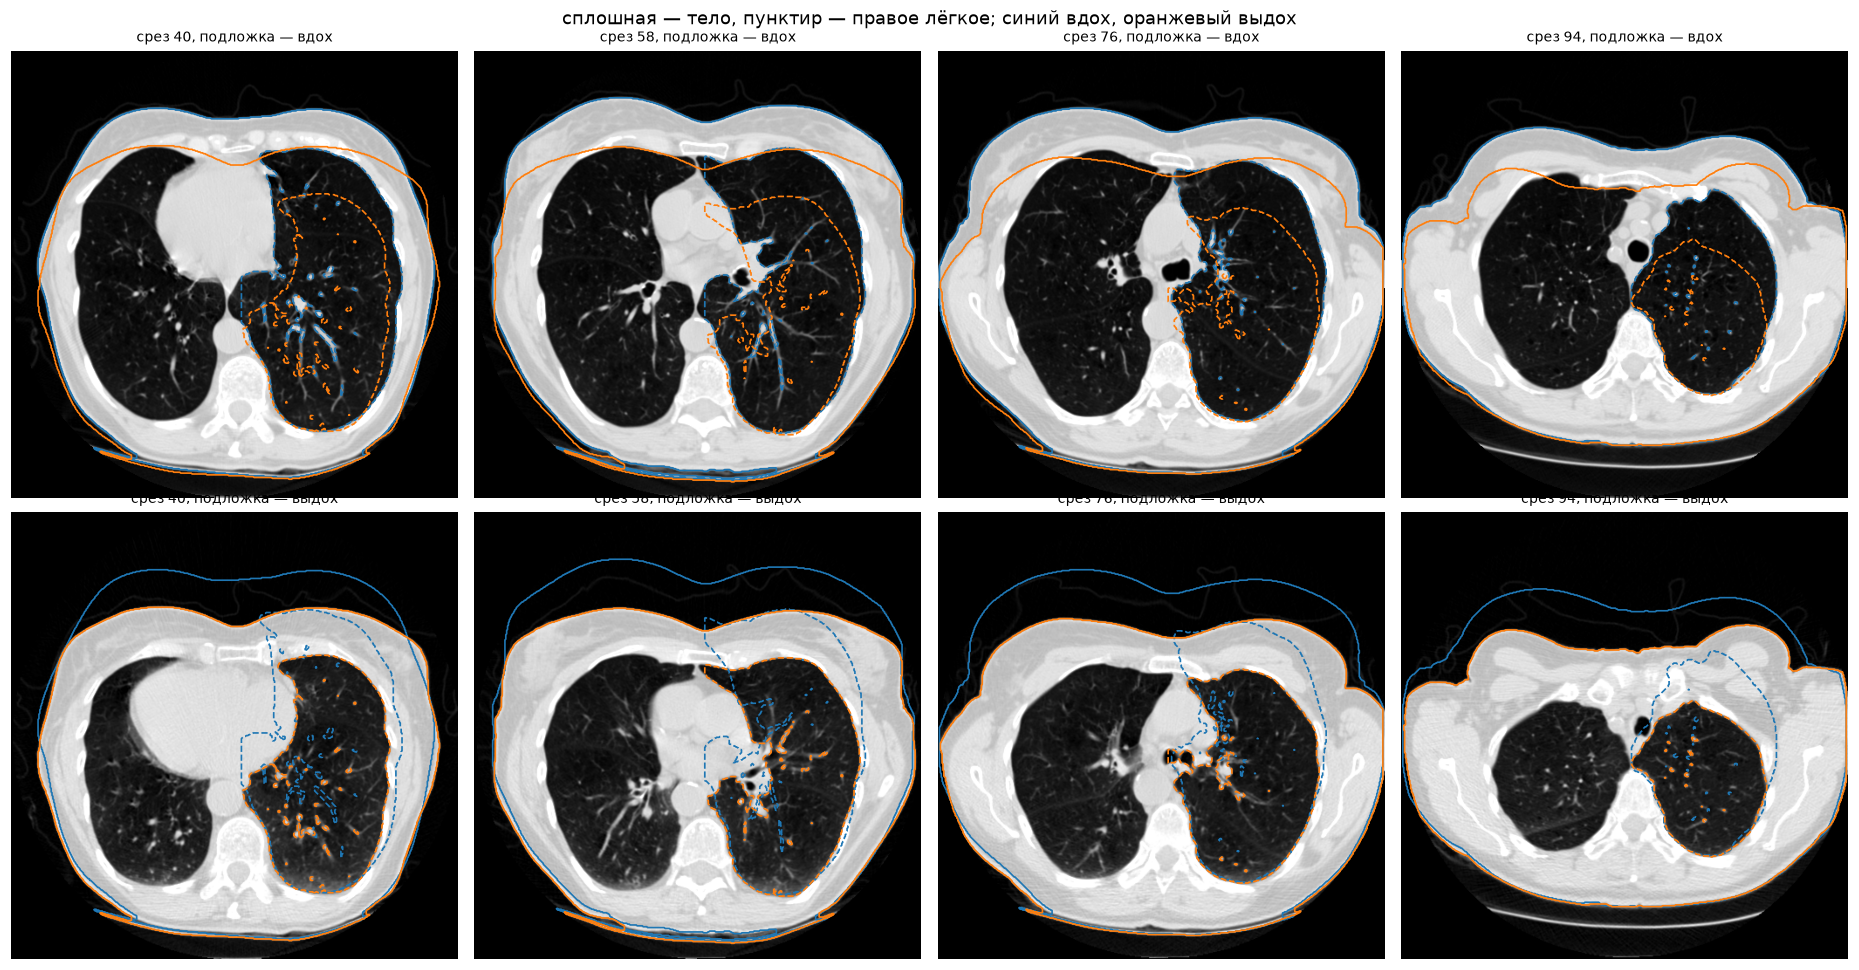

In [9]:
from breathgeom.measure.wall import anatomical_midline

MID = anatomical_midline(inhale, MP)
PHASES = (("вдох", inhale, "tab:blue"), ("выдох", exhale, "tab:orange"))


def contours(axis, index):
    """Тело сплошной линией, правое лёгкое пунктиром, обе фазы."""
    for _, volume, colour in PHASES:
        current = volume[:, :, index]
        mask = body_mask(current, MP)
        if mask is None:
            continue
        axis.contour(mask.T, levels=[0.5], colors=colour, linewidths=1.1)
        lung = lung_mask(current, mask, Side.RIGHT, MP, MID)
        if lung is not None:
            axis.contour(lung.T, levels=[0.5], colors=colour, linewidths=1.1,
                         linestyles="--")


shared = sorted(
    set(k for k in range(inhale.shape[2]) if lung_in[k] > 20)
    & set(k for k in range(exhale.shape[2])
          if (b := body_mask(exhale[:, :, k], MP)) is not None
          and (lg := lung_mask(exhale[:, :, k], b, Side.RIGHT, MP, MID)) is not None
          and float(lg.sum()) * sx * sy / 100.0 > 20)
)
levels = np.linspace(shared[0], shared[-1], 6)[1:5].astype(int)

fig, axes = plt.subplots(2, 4, figsize=(17, 9))
for row, (name, volume, _) in enumerate(PHASES):
    for axis, index in zip(axes[row], levels, strict=True):
        axis.imshow(volume[:, :, index].T, cmap="gray", vmin=-1000, vmax=200,
                    origin="lower")
        contours(axis, index)
        axis.set_title(f"срез {index}, подложка — {name}", fontsize=9)
        axis.axis("off")
fig.suptitle("сплошная — тело, пунктир — правое лёгкое; синий вдох, оранжевый выдох")
fig.tight_layout()
plt.show()

## 10. Смещение границ по углу

Тело одно и то же, поэтому точке поверхности на вдохе отвечает точка на выдохе. Точного
соответствия у нас нет — оно и есть предмет деформируемой регистрации, — поэтому берётся
приближение по радиусу от общего центра: для каждого угла отмечается, где по лучу лежат кожа,
внутренняя граница рёберного каркаса и поверхность лёгкого.

Нижняя панель — разность. Она и отвечает на вопрос, что именно сдвинулось: если кожа и
рёбра стоят, а лёгкое ушло, изменилась не стенка.

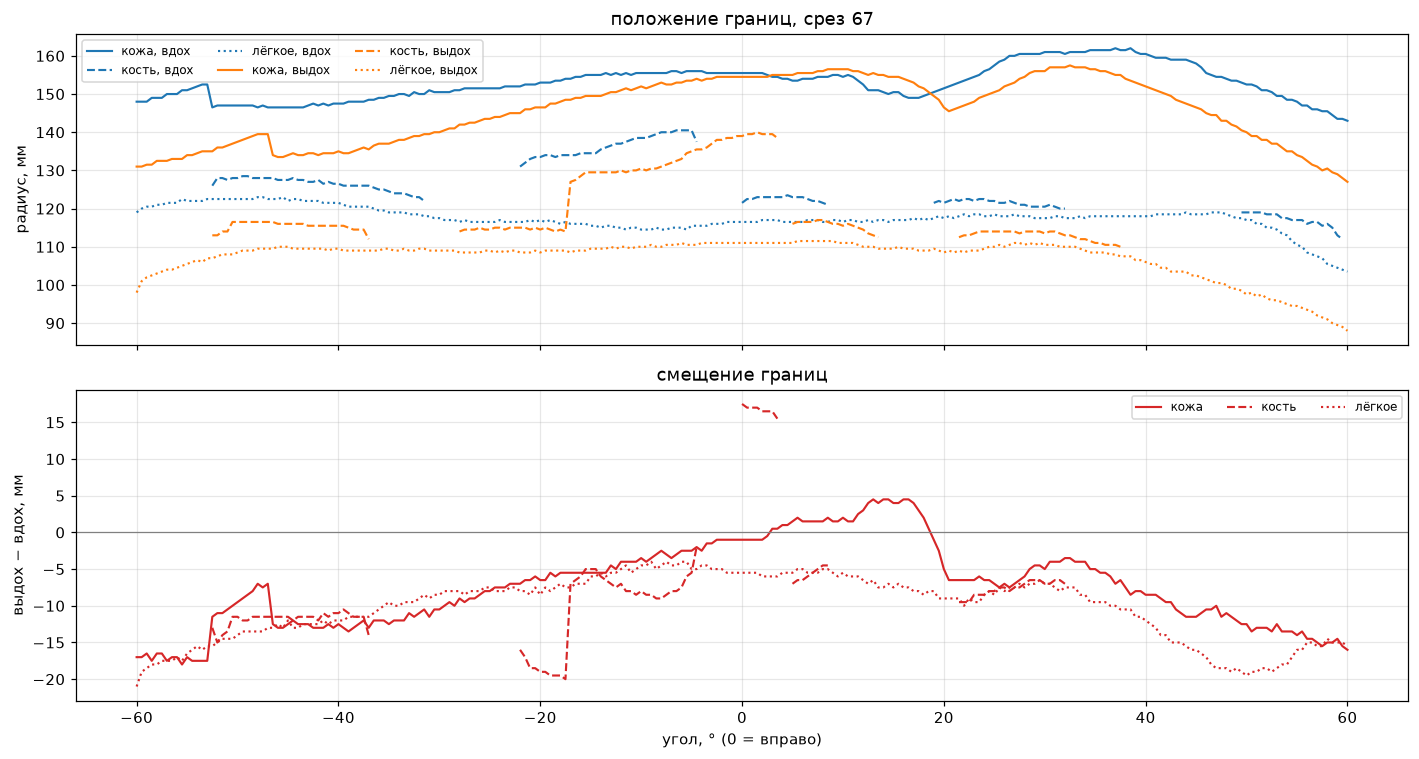

   кожа: медиана  -7.00 мм, размах -18.00.. +4.50
  кость: медиана  -8.50 мм, размах -20.00..+17.50
 лёгкое: медиана  -8.50 мм, размах -21.00.. -4.00


In [10]:
def boundaries(volume, index, angles):
    """Радиусы кожи, кости и лёгкого вдоль лучей из центра тела, мм."""
    current = volume[:, :, index]
    body = body_mask(current, MP)
    lung = lung_mask(current, body, Side.RIGHT, MP, MID)
    centre = ndimage.center_of_mass(body)
    radii = np.arange(1, 500) * 0.5
    out = {key: [] for key in ("кожа", "кость", "лёгкое")}
    for angle in angles:
        rows = np.clip(np.round(centre[0] + radii * np.cos(angle) / sx).astype(int),
                       0, current.shape[0] - 1)
        cols = np.clip(np.round(centre[1] + radii * np.sin(angle) / sy).astype(int),
                       0, current.shape[1] - 1)
        along_body = body[rows, cols]
        out["кожа"].append(radii[np.flatnonzero(along_body)[-1]]
                           if along_body.any() else np.nan)
        bone = along_body & (current[rows, cols] > 200)
        out["кость"].append(radii[np.flatnonzero(bone)[-1]] if bone.any() else np.nan)
        if lung is not None:
            along_lung = lung[rows, cols]
            out["лёгкое"].append(radii[np.flatnonzero(along_lung)[-1]]
                                 if along_lung.any() else np.nan)
        else:
            out["лёгкое"].append(np.nan)
    return {key: np.array(value) for key, value in out.items()}


index = int(np.median(levels))
angles = np.radians(np.linspace(-60, 60, 241))  # правый бок
walls = {name: boundaries(volume, index, angles) for name, volume, _ in PHASES}

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
styles = {"кожа": "-", "кость": "--", "лёгкое": ":"}
for (name, _, colour), marks in zip(PHASES, walls.values(), strict=True):
    for key, style in styles.items():
        ax[0].plot(np.degrees(angles), marks[key], style, color=colour,
                   label=f"{key}, {name}", linewidth=1.4)
for key, style in styles.items():
    ax[1].plot(np.degrees(angles), walls["выдох"][key] - walls["вдох"][key], style,
               color="tab:red", label=key, linewidth=1.4)
ax[1].axhline(0, color="grey", linewidth=0.8)
ax[0].set_ylabel("радиус, мм")
ax[0].set_title(f"положение границ, срез {index}")
ax[1].set_ylabel("выдох − вдох, мм")
ax[1].set_title("смещение границ")
ax[1].set_xlabel("угол, ° (0 = вправо)")
for a in ax:
    a.legend(ncol=3, fontsize=8)
    a.grid(alpha=0.3)
fig.tight_layout()
plt.show()

for key in styles:
    delta = walls["выдох"][key] - walls["вдох"][key]
    print(f"{key:>7}: медиана {np.nanmedian(delta):+6.2f} мм, "
          f"размах {np.nanmin(delta):+6.2f}..{np.nanmax(delta):+6.2f}")

## 11. Компартменты в объёме

Четыре ткани, обе фазы, наложенные друг на друга. Маски строятся по одним и тем же окнам
Хаунсфилда, что и все измерения, и берутся только внутри пояса общих срезов.

Жир и мышца **несжимаемы** за время задержки дыхания: их объём между фазами обязан совпасть.
Это единственная проверка во всей работе, у которой ответ известен заранее, и таблица под
моделями показывает, насколько он не сходится.

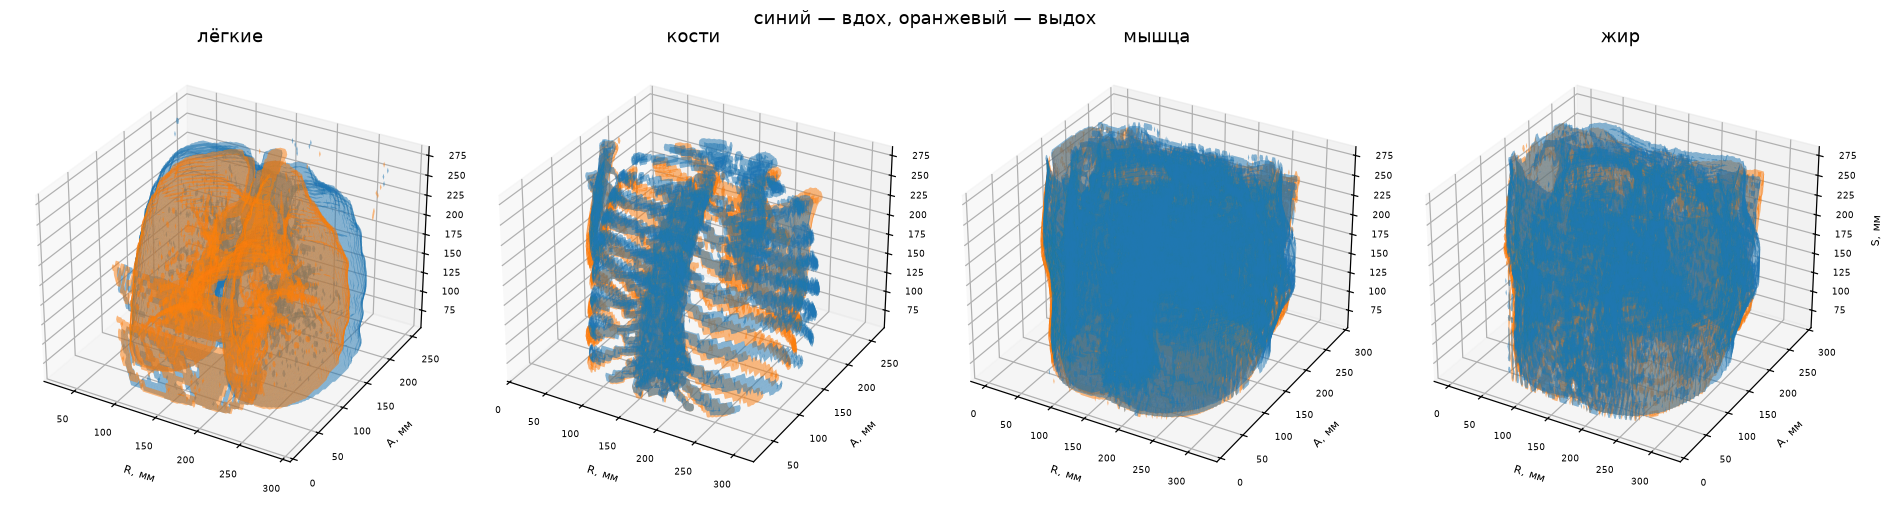

In [11]:
from skimage import measure as skmeasure

BAND = (shared[0], shared[-1])
STEP = 3  # прореживание: марширующие кубы на полном томе избыточны для взгляда

COMPARTMENTS = {
    "лёгкие": lambda hu, body: body & (hu < -400),
    "кости": lambda hu, body: body & (hu > 200),
    "мышца": lambda hu, body: body & (hu >= -29) & (hu <= 150),
    "жир": lambda hu, body: body & (hu >= -190) & (hu <= -30),
}


def compartment(volume, rule):
    mask = np.zeros(volume.shape, dtype=bool)
    for index in range(BAND[0], BAND[1] + 1):
        current = volume[:, :, index]
        body = body_mask(current, MP)
        if body is None:
            continue
        mask[:, :, index] = rule(current, body)
    return mask


masks = {
    name: {phase: compartment(volume, rule) for phase, volume, _ in PHASES}
    for name, rule in COMPARTMENTS.items()
}

fig = plt.figure(figsize=(17, 4.6))
for position, (name, per_phase) in enumerate(masks.items(), start=1):
    axis = fig.add_subplot(1, 4, position, projection="3d")
    for (_phase, _, colour), mask in zip(PHASES, per_phase.values(), strict=True):
        small = mask[::STEP, ::STEP, ::STEP]
        if small.sum() < 100:
            continue
        verts, faces, _, _ = skmeasure.marching_cubes(
            small.astype(np.float32), level=0.5,
            spacing=(sx * STEP, sy * STEP, sz * STEP),
        )
        axis.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                          color=colour, alpha=0.32, linewidth=0, shade=False)
    axis.set_title(name)
    axis.set_xlabel("R, мм", fontsize=7)
    axis.set_ylabel("A, мм", fontsize=7)
    axis.set_zlabel("S, мм", fontsize=7)
    axis.tick_params(labelsize=6)
fig.suptitle("синий — вдох, оранжевый — выдох")
fig.tight_layout()
plt.show()

## 12. Разница по компартментам

Объём и то, куда сместилась ткань. Для несжимаемых тканей первый столбец обязан быть около
нуля; отклонение — это погрешность метода, и меньше неё никакое изменение толщины обсуждать
нельзя.

Смещение центра масс говорит о направлении: если жир и мышца стоят, а лёгкое уехало вверх,
то стенка не изменилась, изменилось положение лёгкого под ней.

   ткань   вдох, мл  выдох, мл   разница | смещение центра масс, мм: R / A / S


  лёгкие       6325       4127    -34.8% |   +1.2 /  -20.0 /   +5.6


   кости        515        533     +3.5% |   +1.3 /   -6.3 /   -0.5


   мышца       4374       4831    +10.4% |   +1.8 /  -10.0 /   -7.3


     жир       2521       2591     +2.8% |   +1.4 /  -13.9 /   -6.5


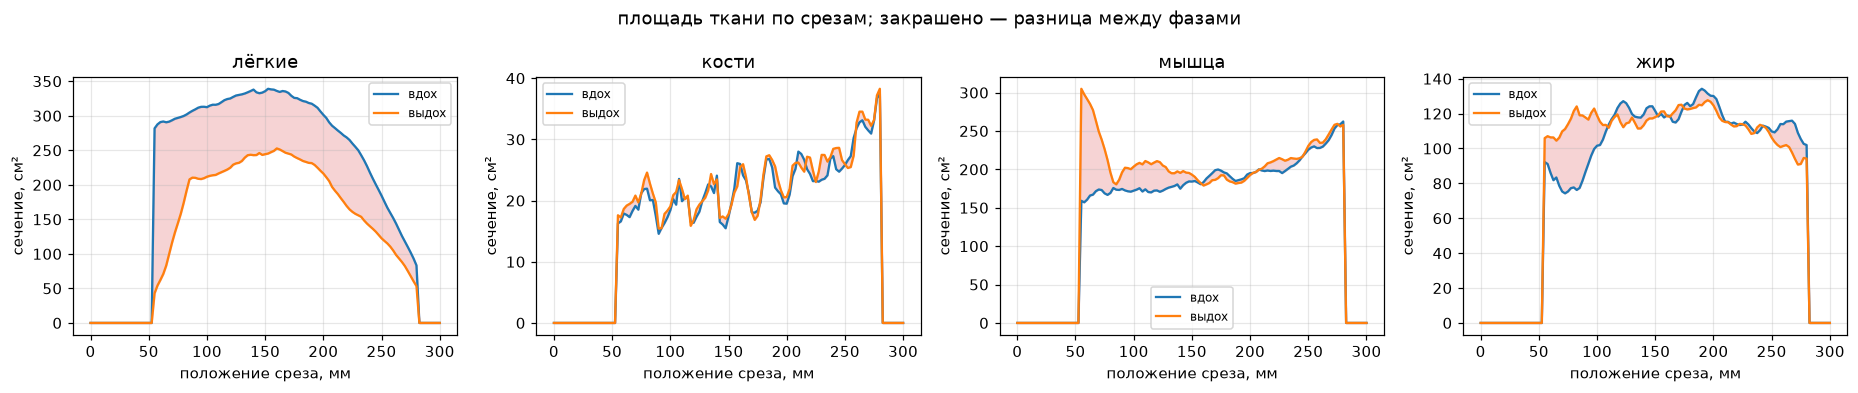

In [12]:
voxel_ml = sx * sy * sz / 1000.0
print(f"{'ткань':>8} {'вдох, мл':>10} {'выдох, мл':>10} {'разница':>9} | "
      f"смещение центра масс, мм: R / A / S")
for name, per_phase in masks.items():
    first, second = per_phase["вдох"], per_phase["выдох"]
    volume_in, volume_ex = first.sum() * voxel_ml, second.sum() * voxel_ml
    shift = (
        np.array(ndimage.center_of_mass(second)) - np.array(ndimage.center_of_mass(first))
    ) * np.array([sx, sy, sz])
    print(f"{name:>8} {volume_in:10.0f} {volume_ex:10.0f} "
          f"{100 * (volume_ex - volume_in) / volume_in:+8.1f}% | "
          f"{shift[0]:+6.1f} / {shift[1]:+6.1f} / {shift[2]:+6.1f}")

fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for axis, (name, per_phase) in zip(axes, masks.items(), strict=True):
    profile_in = per_phase["вдох"].sum(axis=(0, 1)) * sx * sy / 100.0
    profile_ex = per_phase["выдох"].sum(axis=(0, 1)) * sx * sy / 100.0
    z = np.arange(len(profile_in)) * sz
    axis.plot(z, profile_in, color="tab:blue", label="вдох")
    axis.plot(z, profile_ex, color="tab:orange", label="выдох")
    axis.fill_between(z, profile_in, profile_ex, color="tab:red", alpha=0.2)
    axis.set_title(name)
    axis.set_xlabel("положение среза, мм")
    axis.set_ylabel("сечение, см²")
    axis.legend(fontsize=8)
    axis.grid(alpha=0.3)
fig.suptitle("площадь ткани по срезам; закрашено — разница между фазами")
fig.tight_layout()
plt.show()